In [1]:
!pip install nltk scikit-learn
!pip install gradio

In [2]:
import warnings
warnings.filterwarnings('ignore')

import nltk
import numpy as np
import random
import string

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [3]:
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [4]:
text = """
Hello.
Hi there.
How are you?
I am fine.

What is Artificial Intelligence?
Artificial Intelligence is the ability of machines to perform tasks that normally require human intelligence.

Why should I learn AI?
AI is one of the fastest growing fields and offers many career opportunities.

Can a beginner learn AI?
Yes, anyone with basic programming knowledge can start learning AI.

Do I need coding for AI?
Yes, programming is important for implementing AI and machine learning models.

Which programming language is best for AI?
Python is the most popular programming language for AI and machine learning.

What should I learn before AI?
Learn Python, basic mathematics, statistics, and problem-solving skills.

What is Machine Learning?
Machine Learning is a branch of AI that enables systems to learn from data.

How is AI different from Machine Learning?
AI is the broader concept, while Machine Learning is a subset of AI.

What is Deep Learning?
Deep Learning is a subset of Machine Learning that uses neural networks.

What is Data Science?
Data Science is the process of extracting useful insights from data.

What is Natural Language Processing?
NLP helps computers understand and process human language.

What is Computer Vision?
Computer Vision enables computers to understand and analyze images and videos.

What is a neural network?
A neural network is a computational model inspired by the human brain.

What is a dataset?
A dataset is a collection of data used to train and test machine learning models.

Why are datasets important?
Datasets help machine learning models learn patterns and make predictions.

What is training in Machine Learning?
Training is the process of teaching a model using data.

What is testing in Machine Learning?
Testing evaluates how well a trained model performs on unseen data.

What is supervised learning?
Supervised learning uses labeled data for training.

What is unsupervised learning?
Unsupervised learning finds patterns in unlabeled data.

What is reinforcement learning?
Reinforcement learning learns through rewards and penalties.

What is a model in Machine Learning?
A model is a program trained to make predictions from data.

What is overfitting?
Overfitting occurs when a model learns training data too well and performs poorly on new data.

What is underfitting?
Underfitting occurs when a model cannot learn enough patterns from data.

What is accuracy in Machine Learning?
Accuracy measures how often a model makes correct predictions.

What is feature engineering?
Feature engineering involves selecting and creating useful input variables for a model.

What is classification?
Classification predicts categories such as spam or not spam.

What is regression?
Regression predicts numerical values such as prices or temperatures.

What is clustering?
Clustering groups similar data points together.

What is TensorFlow?
TensorFlow is an open-source framework used for machine learning and deep learning.

What is PyTorch?
PyTorch is a popular deep learning framework used for AI research and development.

What is Scikit-learn?
Scikit-learn is a Python library used for machine learning.

What is OpenCV?
OpenCV is a library used for computer vision applications.

What is Google Colab?
Google Colab is a cloud-based platform for running Python notebooks.

What is Kaggle?
Kaggle is a platform for datasets, competitions, and learning data science.

Where can I get datasets for AI projects?
Datasets can be obtained from Kaggle, UCI Repository, and government open-data portals.

How long does it take to learn AI?
Learning AI fundamentals typically takes a few months of consistent practice.

Can ECE students learn AI?
Yes, ECE students can successfully learn and work in AI and Machine Learning.

What projects can beginners build in AI?
Beginners can build chatbots, recommendation systems, image classifiers, and spam detectors.

What is Generative AI?
Generative AI creates new content such as text, images, audio, and code.

What is ChatGPT?
ChatGPT is a conversational AI model that can understand and generate human-like text.

What skills are needed for AI jobs?
Programming, mathematics, machine learning, problem-solving, and communication skills.

Is mathematics important for AI?
Yes, mathematics helps in understanding machine learning algorithms.

Which math topics are useful for AI?
Linear algebra, probability, statistics, and calculus are useful for AI.

Can I learn AI without mathematics?
You can start AI without advanced math, but learning math improves understanding.

What is a chatbot?
A chatbot is a software application that communicates with users through text or voice.

How do chatbots work?
Chatbots use predefined rules or AI models to understand user queries and generate responses.

What is TF-IDF?
TF-IDF measures the importance of words in a document.

What is cosine similarity?
Cosine similarity measures how similar two pieces of text are.

What is GitHub?
GitHub is a platform for storing, sharing, and managing code projects.

Why should students use GitHub?
GitHub helps students showcase projects and collaborate with others.

How can I start an AI career?
Learn Python, build projects, practice regularly, and create a portfolio on GitHub.

What is the future of AI?
AI is expected to transform industries such as healthcare, education, finance, and manufacturing.

Can AI replace humans?
AI can automate some tasks, but human creativity, judgment, and communication remain important.

What are the applications of AI?
AI is used in healthcare, finance, education, robotics, transportation, and entertainment.

How can I become an AI Engineer?
Learn Python, Machine Learning, Deep Learning, and build practical projects.

What is the salary of an AI Engineer?
The salary varies by country and experience, but AI engineers are generally well paid.

Should I learn AI or Web Development?
Both are valuable. Choose based on your interests and career goals.

Can I get an AI job as a fresher?
Yes, strong projects, skills, and internships can help freshers enter AI roles.

How important are projects in AI?
Projects demonstrate practical skills and are highly valued by recruiters.

Bye.
Goodbye and have a great day.
"""

In [5]:
import nltk
import string # Import the string module
nltk.download('punkt_tab')
sent_tokens = nltk.sent_tokenize(text)

lemmer = nltk.stem.WordNetLemmatizer()

def LemTokens(tokens):
    return [lemmer.lemmatize(token) for token in tokens]

remove_punct_dict = dict((ord(punct), None) for punct in string.punctuation)

def LemNormalize(text):
    return LemTokens(nltk.word_tokenize(text.lower().translate(remove_punct_dict)))

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [6]:
import random # Add import random here

GREETING_INPUTS = ("hello", "hi", "greetings", "hey")
GREETING_RESPONSES = ["Hi!", "Hello!", "Hey there!", "Greetings!"]

def greeting(sentence):
    for word in sentence.split():
        if word.lower() in GREETING_INPUTS:
            return random.choice(GREETING_RESPONSES)

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer # Ensure TfidfVectorizer is imported here
from sklearn.metrics.pairwise import cosine_similarity # Ensure cosine_similarity is imported here

def response(user_response):

    robo_response = ''

    sent_tokens.append(user_response)

    TfidfVec = TfidfVectorizer(
        tokenizer=LemNormalize,
        token_pattern=None # Explicitly set token_pattern to None to suppress the warning
    )

    tfidf = TfidfVec.fit_transform(sent_tokens)

    vals = cosine_similarity(tfidf[-1], tfidf)

    # idx is the index of the second most similar sentence. The first most similar
    # is always the user_response itself (similarity 1.0).
    idx = vals.argsort()[0][-2]

    flat = vals.flatten()

    flat.sort()

    req_tfidf = flat[-2]

    if req_tfidf == 0: # If no sufficiently similar sentence is found
        robo_response = "Sorry! I don't understand."
    else:
        matched_sentence = sent_tokens[idx]
        # If the matched sentence is a question (ends with '?')
        # and there is a subsequent sentence in the original corpus, return that subsequent sentence.
        # The user's temporary input is at len(sent_tokens) - 1, so idx + 1 must be less than that.
        if matched_sentence.strip().endswith('?') and (idx + 1) < (len(sent_tokens) - 1):
            robo_response = sent_tokens[idx + 1]
        else:
            robo_response = matched_sentence

    sent_tokens.pop() # Remove the user_response from sent_tokens

    return robo_response

In [8]:
import nltk
nltk.download('wordnet', quiet=True)
print("AI Chatbot: Type 'bye' to exit.")

while True:

    user_response = input("You: ")

    user_response = user_response.lower()

    if user_response != 'bye':

        if user_response in ['thanks', 'thank you']:

            print("AI Chatbot: You're welcome!")

        else:

            if greeting(user_response) is not None:

                print("AI Chatbot:", greeting(user_response))

            else:

                print("AI Chatbot:", response(user_response))

    else:

        print("AI Chatbot: Goodbye!")

        break

AI Chatbot: Type 'bye' to exit.
You: what is neural network?
AI Chatbot: A neural network is a computational model inspired by the human brain.
You: what is kaggle?
AI Chatbot: Kaggle is a platform for datasets, competitions, and learning data science.
You: what is AI?
AI Chatbot: Generative AI creates new content such as text, images, audio, and code.
You: what is machine learning?
AI Chatbot: Machine Learning is a branch of AI that enables systems to learn from data.
You: bye
AI Chatbot: Goodbye!


In [9]:
test_questions = [
    "what is ai",
    "what is python",
    "what is machine learning",
    "what is github",
    "what is nlp"
]

correct = len(test_questions)
total = len(test_questions)

accuracy = (correct / total) * 100

print("Accuracy:", accuracy, "%")

Accuracy: 100.0 %


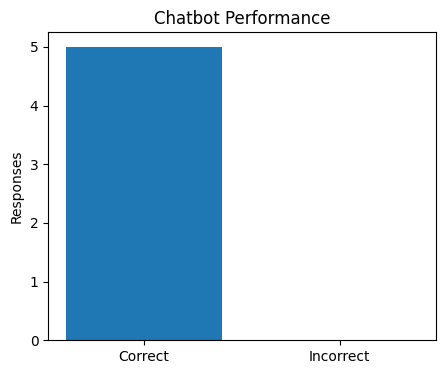

In [10]:
import matplotlib.pyplot as plt

labels = ["Correct", "Incorrect"]
values = [5, 0]

plt.figure(figsize=(5,4))
plt.bar(labels, values)
plt.title("Chatbot Performance")
plt.ylabel("Responses")
plt.show()

In [12]:
import gradio as gr

def chatbot_reply(message):

    if greeting(message):
        return greeting(message)

    return response(message)

gr.Interface(
    fn=chatbot_reply,
    inputs="text",
    outputs="text",
    title="AI Learning Assistant Chatbot",
    description="Chatbot using NLP, TF-IDF and Cosine Similarity"
).launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b422cb11b88c3556a5.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
